# Module 3E — Tire Wear Proxy Regression

Train an XGBoost regressor locally on `logistics_predictive_maintenanceV2.csv`.

The target is `Tire_Wear_pct`, a 0–100 proxy derived from the dataset's Tire Performance Index (`TPI`). It is not a directly measured tread-depth percentage. Raw `TPI` and downstream maintenance/predictive indexes are excluded from the features to prevent target leakage.

This notebook preserves the dataset's predefined Train / Validation / Test partitions and saves `ml/models/tire_wear_model.joblib` only when the held-out quality gate passes.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from datetime import datetime, timezone
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from ml.predictive_maintenance.config import (
    LOGISTICS_TIRE_MODEL_FEATURES,
    LOGISTICS_TIRE_TARGET,
    LOGISTICS_TIRE_TARGET_RAW,
    TIRE_WEAR_MODEL_PATH,
)
from ml.predictive_maintenance.datasets import load_logistics_tire

RANDOM_STATE = 42
MIN_BASELINE_IMPROVEMENT = 0.50
MIN_TEST_R2 = 0.85
MAX_TEST_MAE_PCT = 4.0

print("Repository:", REPO_ROOT)
print("Python:", sys.executable)
print("XGBoost:", xgboost.__version__)
print("Artifact:", TIRE_WEAR_MODEL_PATH)

Repository: F:\BMW
Python: C:\Users\Md. Sayem Kabir\AppData\Local\pypoetry\Cache\virtualenvs\task-ai-tpi11gld-py3.12\Scripts\python.exe
XGBoost: 3.3.0
Artifact: F:\BMW\ml\models\tire_wear_model.joblib


## Load and validate the feature contract

The source already contains a `Data_Split` column. We use it unchanged. The model receives only tire/usage/environment telemetry and engineered ratios; `TPI`, maintenance outcomes, severity, costs, and predictive indexes are not inputs.

In [2]:
frame = load_logistics_tire()
features = list(LOGISTICS_TIRE_MODEL_FEATURES)
target = LOGISTICS_TIRE_TARGET

required = [*features, target, LOGISTICS_TIRE_TARGET_RAW, "Data_Split"]
missing = [column for column in required if column not in frame.columns]
assert not missing, f"Missing columns: {missing}"
assert LOGISTICS_TIRE_TARGET_RAW not in features, "Raw TPI would leak the target"
assert frame[required].notna().all().all(), "Training contract contains missing values"
assert frame[target].between(0.0, 100.0).all()

print(f"Rows: {len(frame):,}")
print("Features:", features)
print("Partitions:\n", frame["Data_Split"].value_counts())
display(frame[[*features, target]].describe().T)

Rows: 250,000
Features: ['Tire_Pressure', 'Vibration_Levels', 'Actual_Load', 'Usage_Hours', 'Days_Since_Last_Maintenance', 'Road_Conditions_code', 'Weather_Conditions_code', 'tire_pressure_deviation', 'load_ratio']
Partitions:
 Data_Split
Train         175000
Test           50000
Validation     25000
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Tire_Pressure,250000.0,33.397201,3.523209,16.875200,31.513900,33.962100,35.841500,44.28260
Vibration_Levels,250000.0,2.042091,1.651715,0.000000,1.011000,1.464600,2.451900,10.70430
Actual_Load,250000.0,6346.029736,5048.893723,525.028400,2039.542650,5077.010500,9456.293225,27496.17180
Usage_Hours,250000.0,11599.770357,6295.169412,300.000000,6164.741925,11610.537150,17042.005500,24350.83290
Days_Since_Last_Maintenance,250000.0,183.060796,149.133783,30.000000,84.000000,138.000000,227.000000,730.00000
Road_Conditions_code,250000.0,2.002964,1.412242,0.000000,1.000000,2.000000,3.000000,4.00000
Weather_Conditions_code,250000.0,2.497528,1.706570,0.000000,1.000000,2.000000,4.000000,5.00000
tire_pressure_deviation,250000.0,2.706339,2.325470,0.000000,0.976500,2.099800,3.748325,17.08690
load_ratio,250000.0,0.622546,0.165183,0.350002,0.493310,0.614596,0.722188,1.09999
Tire_Wear_pct,250000.0,21.278239,10.885086,0.000000,14.020469,17.775396,25.411884,100.00000


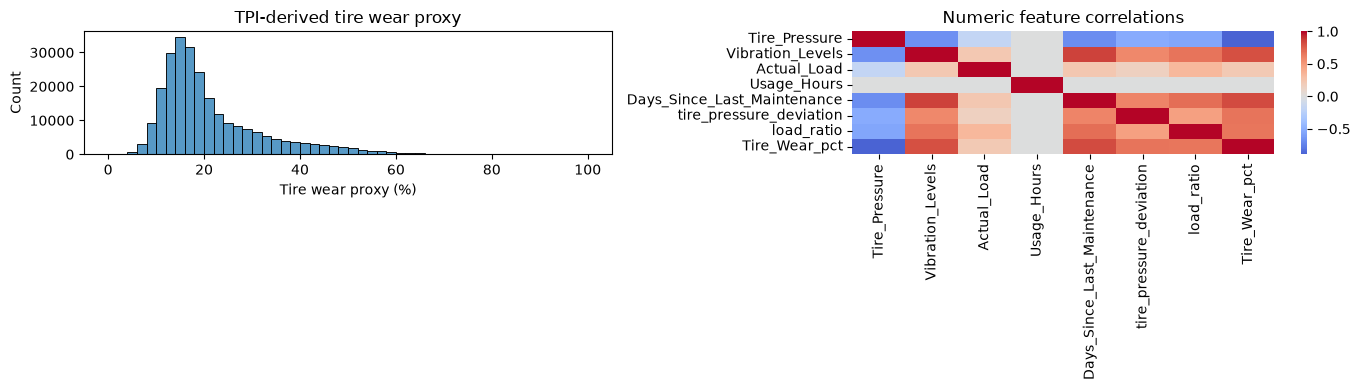

0.00      0.000000
0.50     17.775396
0.90     37.321243
0.95     45.119719
0.99     56.930762
1.00    100.000000
Name: Tire_Wear_pct, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(frame[target], bins=50, ax=axes[0])
axes[0].set(title="TPI-derived tire wear proxy", xlabel="Tire wear proxy (%)")

corr_columns = [
    "Tire_Pressure",
    "Vibration_Levels",
    "Actual_Load",
    "Usage_Hours",
    "Days_Since_Last_Maintenance",
    "tire_pressure_deviation",
    "load_ratio",
    target,
]
sns.heatmap(frame[corr_columns].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Numeric feature correlations")
plt.tight_layout()
plt.show()

print(frame[target].quantile([0, 0.5, 0.9, 0.95, 0.99, 1.0]))

## Predefined train / validation / test split

Validation controls early stopping. The test partition remains untouched until the final quality gate. A constant training-median prediction is the baseline.

In [4]:
split = frame["Data_Split"].astype(str).str.lower()
train_mask = split.eq("train")
val_mask = split.eq("validation")
test_mask = split.eq("test")
assert train_mask.any() and val_mask.any() and test_mask.any()
assert (train_mask | val_mask | test_mask).all()

X_train = frame.loc[train_mask, features].astype(np.float32)
y_train = frame.loc[train_mask, target].astype(np.float32)
X_val = frame.loc[val_mask, features].astype(np.float32)
y_val = frame.loc[val_mask, target].astype(np.float32)
X_test = frame.loc[test_mask, features].astype(np.float32)
y_test = frame.loc[test_mask, target].astype(np.float32)

print(f"Train: {len(X_train):,} | Validation: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Training median baseline: {y_train.median():.2f}%")

Train: 175,000 | Validation: 25,000 | Test: 50,000
Training median baseline: 17.78%


Best iteration: 109
Best validation MAE: 2.509690623216629


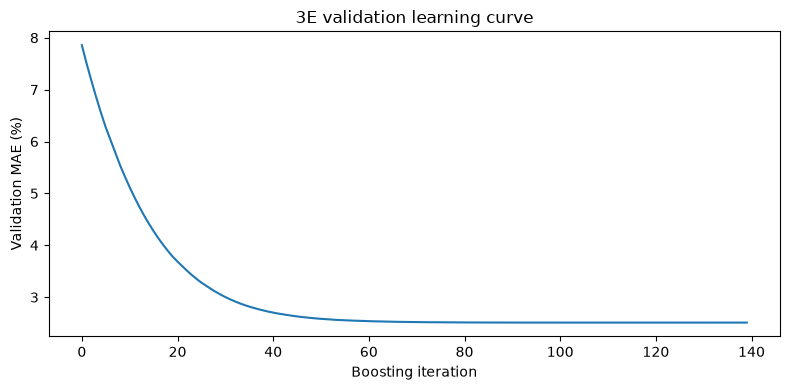

In [5]:
model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.90,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    early_stopping_rounds=30,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

history = model.evals_result()["validation_0"]["mae"]
print("Best iteration:", model.best_iteration)
print("Best validation MAE:", min(history))

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Boosting iteration")
plt.ylabel("Validation MAE (%)")
plt.title("3E validation learning curve")
plt.tight_layout()
plt.show()

## Held-out quality gate

The artifact is eligible for saving only if it materially beats the training-median baseline and reaches practical absolute-error and R² thresholds on the predefined test partition.

Model: {'mae_pct': 2.4765336513519287, 'rmse_pct': 3.116254853429584, 'r2': 0.9180544018745422}
Baseline: {'mae_pct': 7.611546993255615, 'rmse_pct': 11.430412389436267, 'r2': -0.10251212120056152}
MAE improvement: 67.46%
Quality gate passed: True


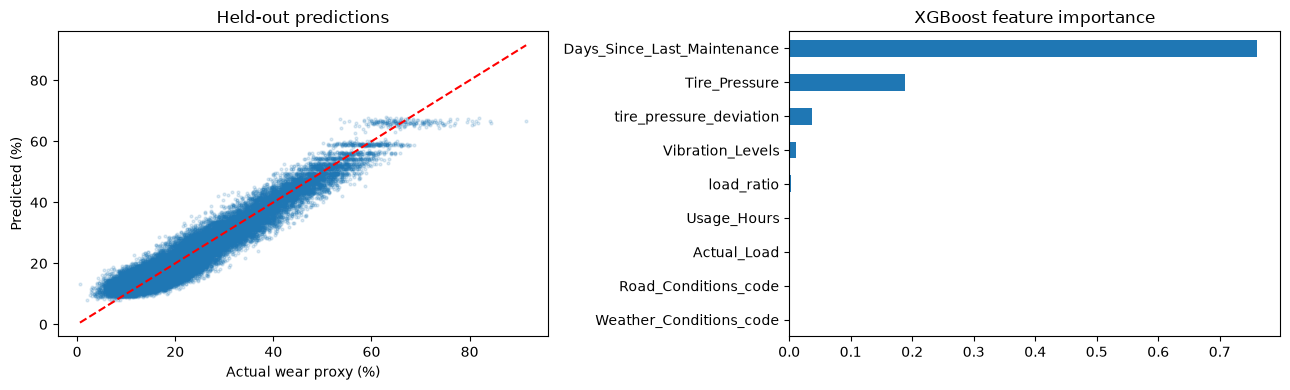

In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "mae_pct": float(mean_absolute_error(y_true, y_pred)),
        "rmse_pct": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }

pred_test = np.clip(model.predict(X_test), 0.0, 100.0)
baseline_test = np.full(len(y_test), float(y_train.median()), dtype=np.float32)
test_metrics = regression_metrics(y_test, pred_test)
baseline_metrics = regression_metrics(y_test, baseline_test)
mae_improvement = 1.0 - test_metrics["mae_pct"] / baseline_metrics["mae_pct"]
quality_gate_passed = (
    test_metrics["mae_pct"] <= MAX_TEST_MAE_PCT
    and test_metrics["r2"] >= MIN_TEST_R2
    and mae_improvement >= MIN_BASELINE_IMPROVEMENT
)

print("Model:", test_metrics)
print("Baseline:", baseline_metrics)
print(f"MAE improvement: {mae_improvement:.2%}")
print("Quality gate passed:", quality_gate_passed)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_test, pred_test, s=4, alpha=0.15)
limits = [float(y_test.min()), float(y_test.max())]
axes[0].plot(limits, limits, "r--")
axes[0].set(xlabel="Actual wear proxy (%)", ylabel="Predicted (%)", title="Held-out predictions")

importance = pd.Series(model.feature_importances_, index=features).sort_values()
importance.plot.barh(ax=axes[1])
axes[1].set_title("XGBoost feature importance")
plt.tight_layout()
plt.show()

## Retrain, save, and reload

After the test gate passes, retrain with Train + Validation using the selected number of trees. The bundle records the exact feature order, observed ranges, category encodings, dependency versions, and held-out metrics.

In [7]:
if quality_gate_passed:
    X_train_final = pd.concat([X_train, X_val], ignore_index=True)
    y_train_final = pd.concat([y_train, y_val], ignore_index=True)
    final_model = XGBRegressor(
        n_estimators=int(model.best_iteration) + 1,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        eval_metric="mae",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    final_model.fit(X_train_final, y_train_final, verbose=False)

    feature_ranges = {
        name: [float(X_train_final[name].min()), float(X_train_final[name].max())]
        for name in features
    }
    category_maps = {
        column: {
            label: index
            for index, label in enumerate(sorted(frame[column].astype(str).unique()))
        }
        for column in ("Road_Conditions", "Weather_Conditions")
    }
    bundle = {
        "schema_version": 1,
        "module": "3E",
        "task": "tpi_derived_tire_wear_regression",
        "model": final_model,
        "features": features,
        "target": target,
        "target_source": LOGISTICS_TIRE_TARGET_RAW,
        "target_semantics": "TPI-derived proxy; not measured tread depth",
        "feature_ranges": feature_ranges,
        "category_maps": category_maps,
        "evaluation": "dataset_predefined_train_validation_test",
        "rows": int(len(frame)),
        "metrics": test_metrics,
        "baseline_metrics": baseline_metrics,
        "mae_improvement": float(mae_improvement),
        "best_iteration": int(model.best_iteration),
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "versions": {
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__,
            "xgboost": xgboost.__version__,
        },
    }
    TIRE_WEAR_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(bundle, TIRE_WEAR_MODEL_PATH)
    print("Saved:", TIRE_WEAR_MODEL_PATH)
else:
    print("Artifact NOT saved: model failed the 3E quality gate.")

Saved: F:\BMW\ml\models\tire_wear_model.joblib


In [8]:
if quality_gate_passed:
    from ml.predictive_maintenance import TireWearPredictor

    reloaded = joblib.load(TIRE_WEAR_MODEL_PATH)
    assert reloaded["features"] == features
    assert reloaded["target"] == target

    sample = X_test.iloc[0].to_dict()
    result = TireWearPredictor().predict(sample)
    print("Reloaded bundle successfully")
    print("Sample prediction:", result)
    print("Actual wear proxy:", float(y_test.iloc[0]))

Reloaded bundle successfully
Sample prediction: TireWearResult(wear_pct=13.470152854919434, severity='normal', maintenance_required=False, within_training_range=True)
Actual wear proxy: 13.086923599243164
